# Choropleth Map & CHORD Chart - Data Analysis Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

In [2]:
# Read json files from ../src/json/fips.json
# FIPS 10-4 to Country Name mapping
with open('../src/json/fips.json', 'r') as f:
    fips = json.load(f)

In [3]:
# Function to convert 2-letter FIPS 10-4 country codes to country names
def code_to_country(code):
    try:
        country = fips[code]
        return country
    except:
        raise ValueError(f"Invalid country code: {code}")

In [4]:
# Load the mentions dataset from data/GDELT/weekly_media_attention_query_class34_better_disambiguation.csv
# The old dataset
# path_mentions = "../data/GDELT/weekly_media_attention_query_class34_better_disambiguation.csv"

# The new one
path_mentions = "../data/GDELT/2026_weekly_media_attention_query_class34_better_disambiguation.csv"
df_mentions = pd.read_csv(path_mentions)

# Display the first few rows of the dataframe
df_mentions.head()

,mention_week,conflict_country,media_country,mentions_count,distinct_events,verbal_conflict_mentions,material_conflict_mentions,verbal_conflict_unique_events,material_conflict_unique_events,state_mentions,...,civilians_unique_events,international_mentions,international_unique_events,avg_tone,stddev_tone,median_tone,avg_impact,stddev_impact,median_impact,top_article_url
0,2026-01-12,SO,Qatar,40,40,30,10,30,10,14,...,8,0,0,-3.171341,2.118406,-3.530633,-4.092500,2.276681,-4.0,https://arabic.arabianbusiness.com/arab-world-...
1,2026-01-12,SY,Lebanon,89,54,30,59,21,33,27,...,20,0,0,-5.492157,1.443785,-5.625000,-6.984270,2.825247,-7.2,https://www.hazard-herald.com/news/national/ni...
2,2026-01-12,SF,USA,9,9,3,6,3,6,6,...,2,0,0,-8.458729,2.266588,-10.081744,-7.333333,4.000000,-10.0,https://www.ksl.com:443/article/51431658/landm...
3,2026-01-12,FR,South Africa,13,13,10,3,10,3,4,...,2,3,3,-2.448098,2.758378,-1.459854,-5.115385,2.836913,-6.5,https://www.ewn.co.za/2026/01/15/musks-grok-ba...
4,2026-01-12,CO,Australia,16,4,16,0,4,0,16,...,0,0,0,-3.170181,0.014790,-3.180212,-4.400000,0.000000,-4.4,https://www.bunburymail.com.au/story/9152906/a...


In [5]:
# Convert the 'conflict_country' column from FIPS 10-4 codes to country names
df_mentions['conflict_country_name'] = df_mentions['conflict_country'].apply(code_to_country)

In [6]:
# Display the first few rows of the dataframe
df_mentions.head()

,mention_week,conflict_country,media_country,mentions_count,distinct_events,verbal_conflict_mentions,material_conflict_mentions,verbal_conflict_unique_events,material_conflict_unique_events,state_mentions,...,international_mentions,international_unique_events,avg_tone,stddev_tone,median_tone,avg_impact,stddev_impact,median_impact,top_article_url,conflict_country_name
0,2026-01-12,SO,Qatar,40,40,30,10,30,10,14,...,0,0,-3.171341,2.118406,-3.530633,-4.092500,2.276681,-4.0,https://arabic.arabianbusiness.com/arab-world-...,Somalia
1,2026-01-12,SY,Lebanon,89,54,30,59,21,33,27,...,0,0,-5.492157,1.443785,-5.625000,-6.984270,2.825247,-7.2,https://www.hazard-herald.com/news/national/ni...,Syria
2,2026-01-12,SF,USA,9,9,3,6,3,6,6,...,0,0,-8.458729,2.266588,-10.081744,-7.333333,4.000000,-10.0,https://www.ksl.com:443/article/51431658/landm...,South Africa
3,2026-01-12,FR,South Africa,13,13,10,3,10,3,4,...,3,3,-2.448098,2.758378,-1.459854,-5.115385,2.836913,-6.5,https://www.ewn.co.za/2026/01/15/musks-grok-ba...,France
4,2026-01-12,CO,Australia,16,4,16,0,4,0,16,...,0,0,-3.170181,0.014790,-3.180212,-4.400000,0.000000,-4.4,https://www.bunburymail.com.au/story/9152906/a...,Colombia


For doing the conversion in a way that all country codes are associated with their country names we used the official FIPS-10-4 list with some added codes that can be found in GDELT. The following few lines show all this.

In [7]:
# Reading ../src/json/fips_extension.json for extended FIPS codes
with open('../src/json/fips_extension.json', 'r') as f:
    fips_extension = json.load(f)

In [8]:
# Extracting the number of mentions for country codes in fips_extension
mentions_extension = {}
for code in fips_extension.keys():
    count = df_mentions[df_mentions['conflict_country'] == code].shape[0]
    mentions_extension[code] = count

# Print the mentions for the extension codes and the percentage of total mentions they represent
total_mentions = df_mentions.shape[0]

for code, count in mentions_extension.items():
    percentage = (count / total_mentions) * 100
    country_name = fips_extension[code]
    print(f"{country_name} ({code}): {count} mentions, {percentage:.2f}% of total")


Oceania (OC): 633 mentions, 0.03% of total
Oceans (OS): 4772 mentions, 0.25% of total
Serbia (RB): 8387 mentions, 0.44% of total
Serbia (YI): 997 mentions, 0.05% of total
Howland Island (HQ): 9 mentions, 0.00% of total
Kingman Reef (KQ): 2 mentions, 0.00% of total
Johnston Atoll (JQ): 3 mentions, 0.00% of total
Jarvis Island (DQ): 3 mentions, 0.00% of total
Palmyra Atoll (LQ): 1 mentions, 0.00% of total


The countries which have been added are not that relevant with respect to mentions, but we'll keep for now.

We will then drop some columns which will not be used in the Choropleth map.

### General Mentions

In this first dataset we will extract we keep the aggregated columns 'mentions_count' and 'distinct_events' which also contain verbal conflict events.

In a following section we will extract another dataset containing only material conflict events and their respective mentions

In [9]:
columns_to_keep = ['mention_week', 'conflict_country_name', 'media_country', 'mentions_count', 'distinct_events']
df_mentions_filtered = df_mentions[columns_to_keep]
df_mentions_filtered.head()

,mention_week,conflict_country_name,media_country,mentions_count,distinct_events
0,2026-01-12,Somalia,Qatar,40,40
1,2026-01-12,Syria,Lebanon,89,54
2,2026-01-12,South Africa,USA,9,9
3,2026-01-12,France,South Africa,13,13
4,2026-01-12,Colombia,Australia,16,4


In [10]:
# For each 'media_country' and 'mention_week', keep the 5 rows with the highest 'mentions_count'
n = 5
df_top_mentions = df_mentions_filtered.sort_values('mentions_count', ascending=False).groupby(['media_country', 'mention_week']).head(n)
df_top_mentions.head()

,mention_week,conflict_country_name,media_country,mentions_count,distinct_events
1587610,2016-07-04,United States,Other,826177,131899
1459566,2017-01-30,United States,Other,749945,176454
1585675,2016-07-11,United States,Other,715647,140692
1580190,2016-07-18,United States,Other,690476,139554
1455982,2017-02-06,United States,Other,666873,150383


In [11]:
# Sort by 'mention_week' and 'media_country'
df_top_mentions = df_top_mentions.sort_values(by=['mention_week', 'media_country'])
df_top_mentions.head()

,mention_week,conflict_country_name,media_country,mentions_count,distinct_events
1897037,2015-02-16,Afghanistan,Afghanistan,99,89
1896630,2015-02-16,Pakistan,Afghanistan,29,21
1895645,2015-02-16,Turkey,Afghanistan,7,7
1896860,2015-02-16,United States,Afghanistan,6,6
1895347,2015-02-16,Algeria,Algeria,12,9


For testing reasons I wanted to see what were the top five mentions in Italy in the various years at a glance.

In [12]:
# Find rows where 'media_country' is 'Italy' and print them
df_top_mentions[df_top_mentions['media_country'] == 'Italy']

,mention_week,conflict_country_name,media_country,mentions_count,distinct_events
1894503,2015-02-16,Italy,Italy,1536,942
1894645,2015-02-16,Libya,Italy,273,155
1895917,2015-02-16,Netherlands,Italy,229,57
1894948,2015-02-16,Germany,Italy,211,75
1895519,2015-02-16,Russia,Italy,155,84
...,...,...,...,...,...
900,2026-01-12,Italy,Italy,2185,1510
1506,2026-01-12,Iran,Italy,878,613
1229,2026-01-12,United States,Italy,382,296
1037,2026-01-12,Ukraine,Italy,259,170


Some strange behavior seems to be happening, at least for Italy: the top country seems always the media reporting one! 
Maybe it is because of verbal conflicts. Let's just keep material ones now.

## Material Conflict Only

In [13]:
columns_to_keep = ['mention_week', 'conflict_country_name', 'media_country', 'material_conflict_mentions', 'material_conflict_unique_events']
df_mentions_filtered_material = df_mentions[columns_to_keep]
df_mentions_filtered_material.head()

,mention_week,conflict_country_name,media_country,material_conflict_mentions,material_conflict_unique_events
0,2026-01-12,Somalia,Qatar,10,10
1,2026-01-12,Syria,Lebanon,59,33
2,2026-01-12,South Africa,USA,6,6
3,2026-01-12,France,South Africa,3,3
4,2026-01-12,Colombia,Australia,0,0


In [14]:
df_top_mentions_material = df_mentions_filtered_material.sort_values('material_conflict_mentions', ascending=False).groupby(['media_country', 'mention_week']).head(n)
df_top_mentions_material = df_top_mentions_material.sort_values(by=['mention_week', 'media_country'])
df_top_mentions_material.head()

,mention_week,conflict_country_name,media_country,material_conflict_mentions,material_conflict_unique_events
1897037,2015-02-16,Afghanistan,Afghanistan,66,58
1896630,2015-02-16,Pakistan,Afghanistan,24,17
1896860,2015-02-16,United States,Afghanistan,5,5
1895645,2015-02-16,Turkey,Afghanistan,0,0
1894183,2015-02-16,Libya,Algeria,6,6


In [15]:
# List of media_country:
media_countries = df_top_mentions_material['media_country'].unique()
conflict_countries = df_top_mentions_material['conflict_country_name'].unique()

In [16]:
print(media_countries)

['Afghanistan' 'Algeria' 'Argentina' 'Australia' 'Austria' 'Bahrain'
 'Bangladesh' 'Belgium' 'Bolivia' 'Brazil' 'Bulgaria' 'Canada' 'Chile'
 'China' 'Colombia' 'Costa Rica' 'Croatia' 'Cuba' 'Czech Republic'
 'Denmark' 'Ecuador' 'Egypt' 'Finland' 'France' 'Germany' 'Ghana' 'Greece'
 'Hungary' 'Iceland' 'India' 'Indonesia' 'Iran' 'Iraq' 'Ireland' 'Israel'
 'Italy' 'Jamaica' 'Japan' 'Jordan' 'Kazakhstan' 'Kenya' 'Kuwait'
 'LatAm (Left-Wing Block)' 'Lebanon' 'Libya' 'Malaysia' 'Mexico' 'Morocco'
 'Myanmar' 'Netherlands' 'New Zealand' 'Nigeria' 'Norway' 'Oman' 'Other'
 'Pakistan' 'Pan-Africa' 'Panama' 'Paraguay' 'Peru' 'Philippines' 'Poland'
 'Portugal' 'Qatar' 'Romania' 'Russia' 'Saudi Arabia' 'Senegal' 'Serbia'
 'Singapore' 'Slovakia' 'South Africa' 'South Korea' 'Spain' 'Sri Lanka'
 'Sweden' 'Switzerland' 'Syria' 'Tanzania' 'Thailand'
 'Trinidad and Tobago' 'Tunisia' 'Turkey' 'UAE' 'UK' 'USA' 'Uganda'
 'Ukraine' 'Uruguay' 'Venezuela' 'Vietnam' 'Zimbabwe' 'Nepal' 'Uzbekistan'
 'Ethiopia' 

In [17]:
print(conflict_countries)

['Afghanistan' 'Pakistan' 'United States' 'Turkey' 'Libya' 'Algeria'
 'Argentina' 'Sweden' 'Iran' 'Uruguay' 'Chile' 'Australia' 'Indonesia'
 'Iraq' 'Nigeria' 'Ukraine' 'Russia' 'Syria' 'Egypt' 'Bangladesh'
 'Belgium' 'Bolivia' 'Venezuela' 'Peru' 'Brazil' 'Bulgaria' 'Greece'
 'Canada' 'United Kingdom' 'China' 'Colombia' 'Costa Rica' 'Croatia'
 'India' 'Cuba' 'Czech Republic' 'Belarus' 'Denmark' 'France' 'Germany'
 'Ecuador' 'Finland' 'Ghana' 'South Africa' 'Niger' 'Hungary' 'Iceland'
 'Thailand' 'Ireland' 'Israel' 'Italy' 'Netherlands' 'Jamaica' 'Japan'
 'Jordan' 'Kazakhstan' 'Kenya' 'Somalia' 'Mexico' 'Lebanon' 'Tunisia'
 'Malaysia' 'Morocco' 'Chad' 'Myanmar' 'New Zealand' 'Norway' 'Yemen'
 'Oman' 'Zimbabwe' 'Panama' 'Spain' 'Paraguay' 'Philippines' 'Poland'
 'Portugal' 'Romania' 'Saudi Arabia' 'Senegal' 'Serbia' 'Slovakia'
 'South Korea' 'North Korea' 'Sri Lanka' 'Uzbekistan' 'Switzerland'
 'Tanzania' 'Trinidad and Tobago' 'United Arab Emirates' 'Uganda' 'Sudan'
 'Vietnam' 'Austria' '

Inspecting at a glance this behavior by building some small multiples scatterplots with the top-1 mention for each week and each media_country

In [18]:
# for all media countries (expect for 'LatAm (Left-Wing Block)' and 'Other' and 'Pan-Africa'), for all weeks, get the conflict_country_name with highest material_conflict_mentions. 
# If it is different than the media_country, we will save this fact for further use.

media_countries_filtered = ['Italy', 'UAE', 'UK', 'USA', 'France', 'Germany', 'Greece', 'Australia', 'China', 'India']

media_coverage = {}

for media_country in media_countries_filtered:
    if media_country in ['LatAm (Left-Wing Block)', 'Other', 'Pan-Africa']:
        continue
    media_coverage[media_country] = {}
    df_media = df_top_mentions_material[df_top_mentions_material['media_country'] == media_country]
    for week in df_media['mention_week'].unique():
        media_coverage[media_country][week] = {}
        df_week = df_media[df_media['mention_week'] == week]
        top_conflict = df_week.iloc[0]
        if media_country == 'UK':
            media_country_key = 'United Kingdom'
        elif media_country == 'USA':
            media_country_key = 'United States'
        elif media_country == 'UAE':
            media_country_key = 'United Arab Emirates'
        else:
            media_country_key = media_country
        if top_conflict['conflict_country_name'] != media_country_key:
            media_coverage[media_country][week]['country_name'] = top_conflict['conflict_country_name']
            media_coverage[media_country][week]['mentions'] = top_conflict['material_conflict_mentions']

In [19]:
# Here we are interested instead to see the top-1 mention, disregarding the fact that a country mention itself

media_coverage_total = {}

for media_country in media_countries_filtered:
    if media_country in ['LatAm (Left-Wing Block)', 'Other', 'Pan-Africa']:
        continue
    media_coverage_total[media_country] = {}
    df_media = df_top_mentions_material[df_top_mentions_material['media_country'] == media_country]
    for week in df_media['mention_week'].unique():
        media_coverage_total[media_country][week] = {}
        df_week = df_media[df_media['mention_week'] == week]
        top_conflict = df_week.iloc[0]
        media_coverage_total[media_country][week]['country_name'] = top_conflict['conflict_country_name']
        media_coverage_total[media_country][week]['mentions'] = top_conflict['material_conflict_mentions']

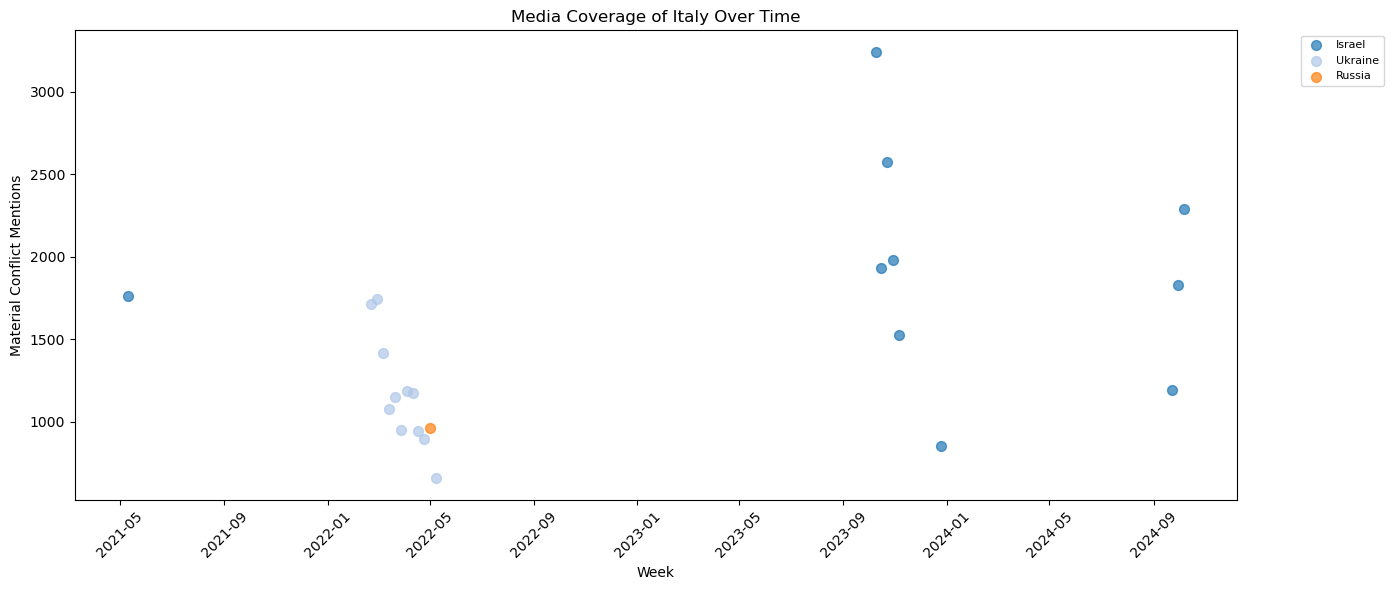

In [20]:
# Plot just for Italy
weeks = []
mentions = []
country_names = []
for week, data in media_coverage['Italy'].items():
    if data != {}:  # Only include non-empty data
        weeks.append(week)
        mentions.append(data['mentions'])
        country_names.append(data['country_name'])

# Convert weeks to datetime for better plotting
weeks_dt = pd.to_datetime(weeks)

plt.figure(figsize=(14, 6))
unique_countries = list(set(country_names))
colors = plt.cm.tab20(range(len(unique_countries)))
color_map = {country: colors[i] for i, country in enumerate(unique_countries)}

for country in unique_countries:
    indices = [i for i, c in enumerate(country_names) if c == country]
    plt.scatter([weeks_dt[i] for i in indices], [mentions[i] for i in indices], 
                label=country, s=50, alpha=0.7, color=color_map[country])

plt.xlabel('Week')
plt.ylabel('Material Conflict Mentions')
plt.title('Media Coverage of Italy Over Time')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


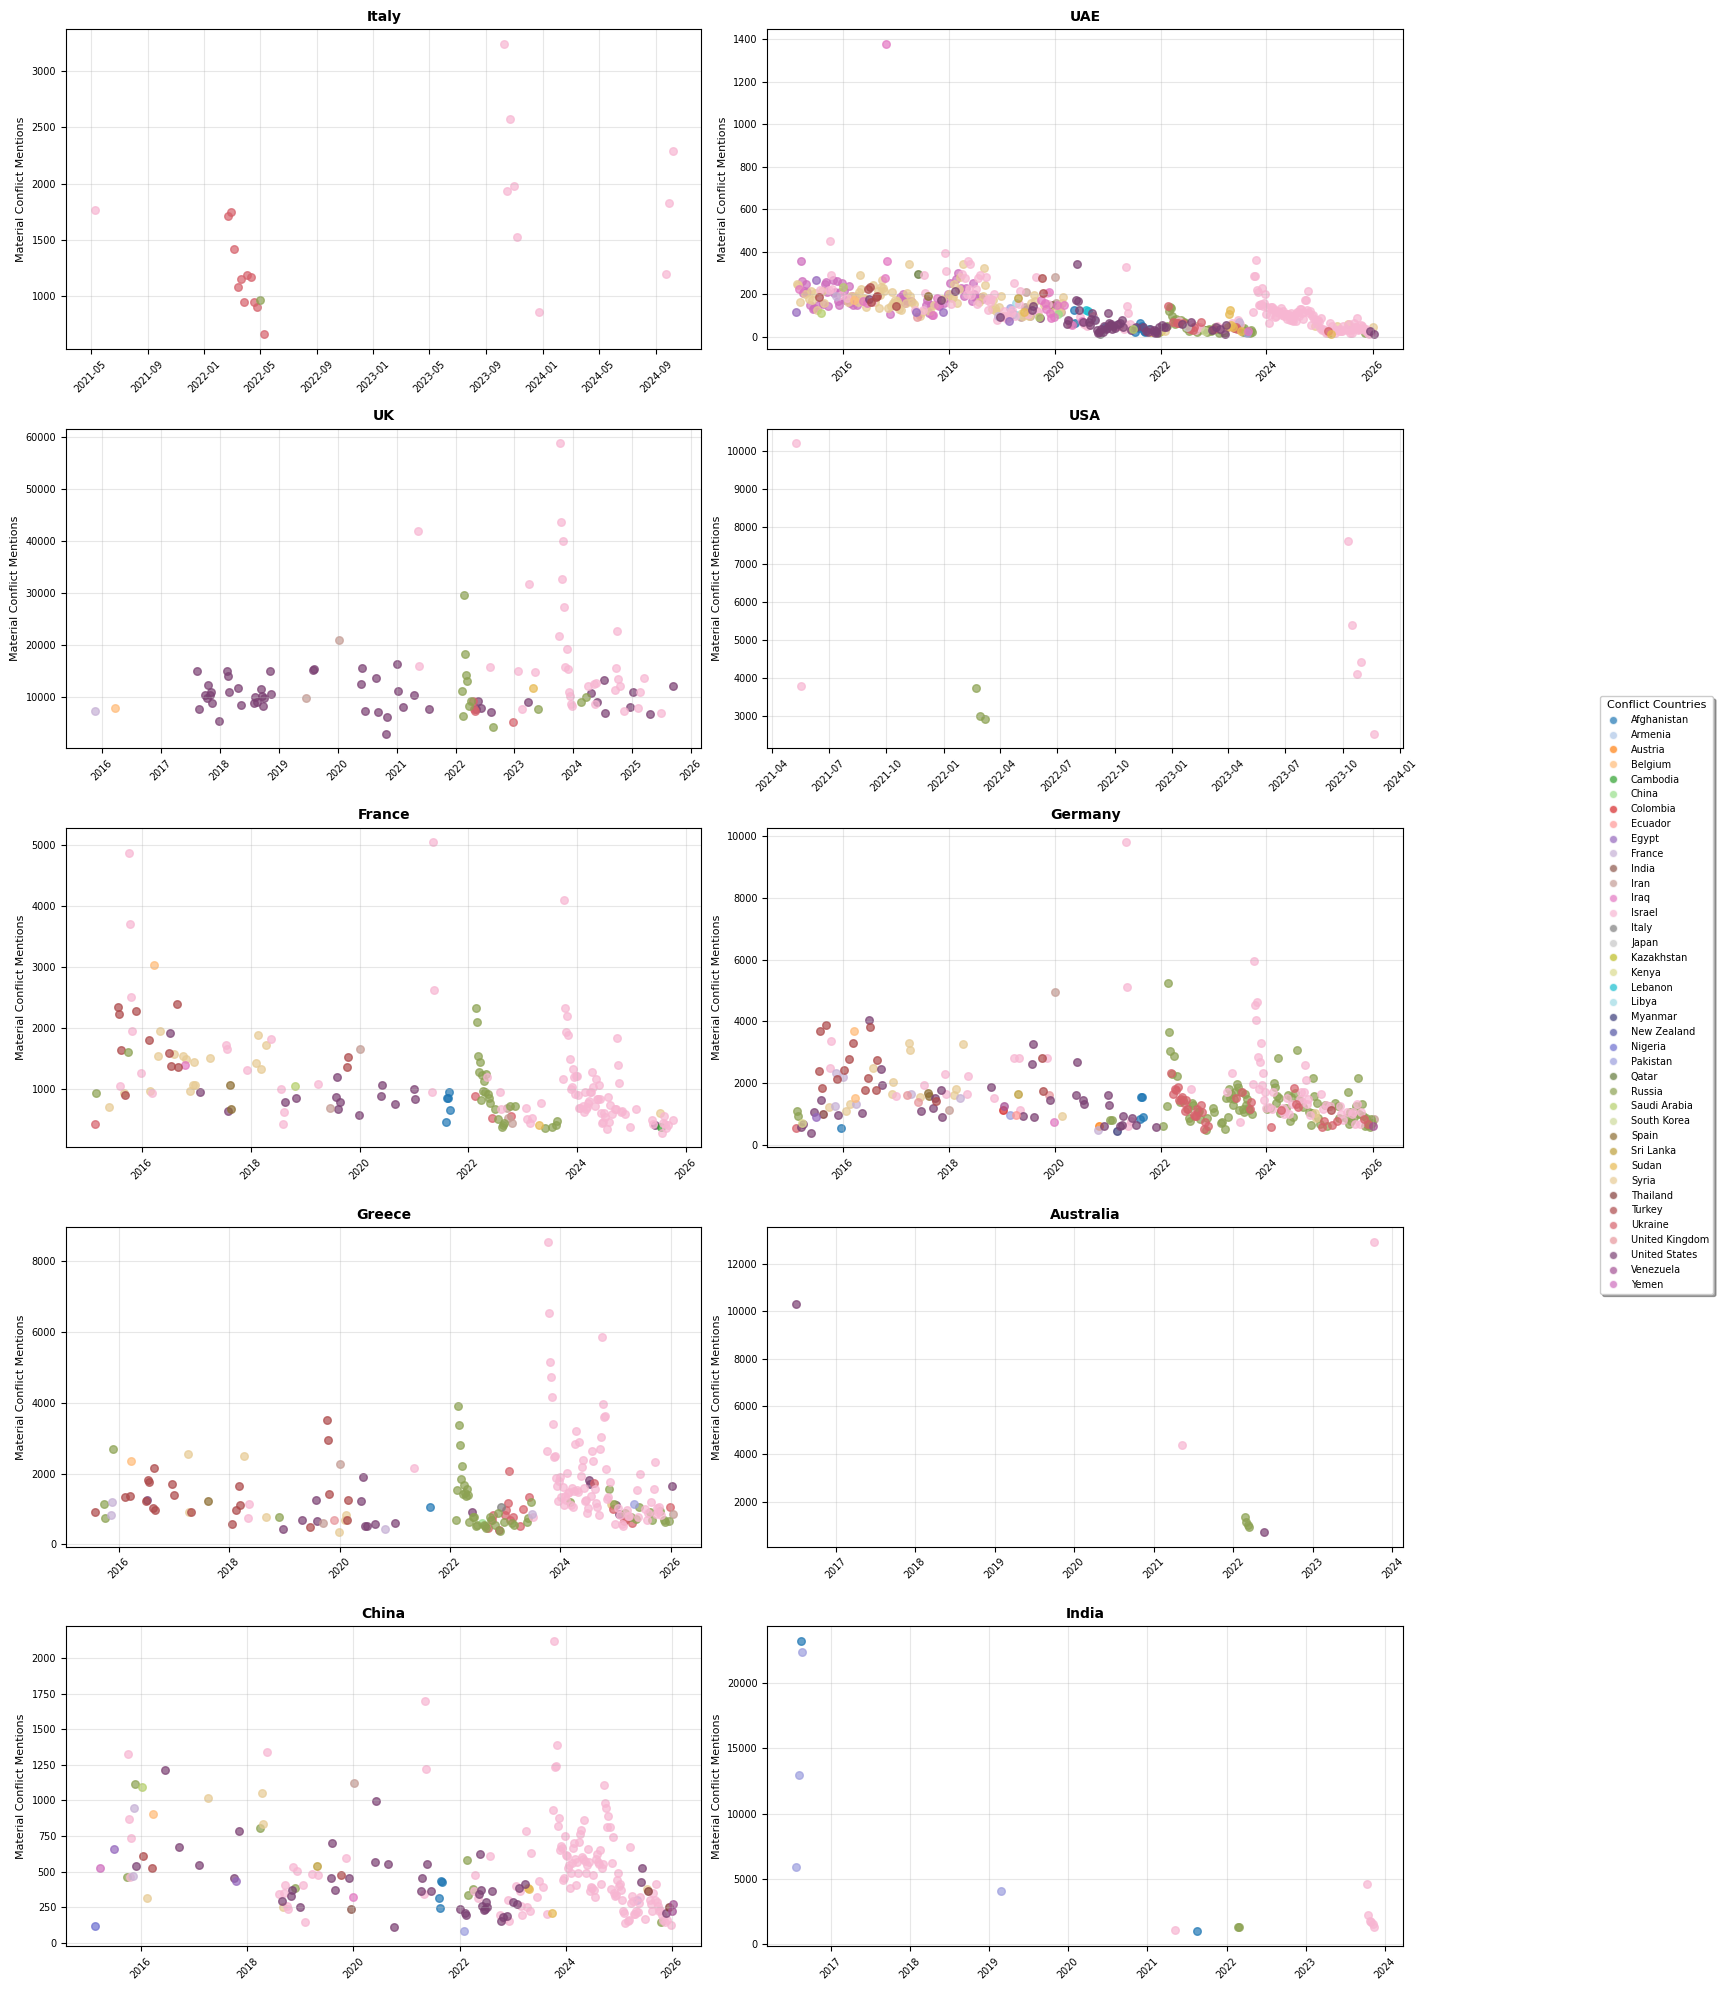

In [21]:
# Count actual countries to plot (excluding the 3 skipped ones)
countries_to_plot = [mc for mc in media_countries_filtered 
                     if mc not in ['LatAm (Left-Wing Block)', 'Other', 'Pan-Africa']]

# First pass: check which countries actually have data
countries_with_data = []
all_countries = set()

for media_country in countries_to_plot:
    country_key = media_country
    
    has_data = False
    for week, data in media_coverage[country_key].items():
        if data != {}:
            has_data = True
            all_countries.add(data['country_name'])
    
    #if has_data:
    countries_with_data.append(media_country)

n_countries = len(countries_with_data)

# Calculate grid size needed
n_cols = 2
n_rows = (n_countries + n_cols - 1) // n_cols  # Ceiling division

# Create the grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
if n_rows == 1:
    axes = [axes] if n_cols == 1 else axes
else:
    axes = axes.flatten()

# Create diverse color map with enough colors
all_countries = sorted(list(all_countries))
n_colors = len(all_countries)

# Use multiple color maps to get distinct colors
if n_colors <= 20:
    colors = plt.cm.tab20(range(n_colors))
else:
    # Combine multiple colormaps for more distinct colors
    colors1 = plt.cm.tab20(range(20))
    colors2 = plt.cm.tab20b(range(min(20, n_colors - 20)))
    colors3 = plt.cm.tab20c(range(max(0, n_colors - 40)))
    colors = list(colors1) + list(colors2) + list(colors3)
    colors = colors[:n_colors]

color_map = {country: colors[i] for i, country in enumerate(all_countries)}

# Plot each media country that has data
idx = 0
for media_country in countries_with_data:
    country_key = media_country
    
    weeks = []
    mentions = []
    country_names = []
    for week, data in media_coverage[country_key].items():
        if data != {}:
            weeks.append(week)
            mentions.append(data['mentions'])
            country_names.append(data['country_name'])
    
    weeks_dt = pd.to_datetime(weeks)
    ax = axes[idx]
    
    unique_countries = list(set(country_names))
    
    for country in unique_countries:
        indices = [i for i, c in enumerate(country_names) if c == country]
        ax.scatter([weeks_dt[i] for i in indices], [mentions[i] for i in indices], 
                   s=30, alpha=0.7, color=color_map[country])
    
    ax.set_title(f'{country_key}', fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)
    ax.set_ylabel('Material Conflict Mentions', fontsize=8)
    ax.grid(True, alpha=0.3)
    
    idx += 1

# Hide unused subplots (if any)
for i in range(idx, len(axes)):
    axes[i].set_visible(False)

# Create shared legend with smaller font if many countries
legend_fontsize = 7 if n_colors > 30 else 8
handles = [plt.Line2D([0], [0], marker='o', color='w', 
                      markerfacecolor=color_map[country], 
                      markersize=6, alpha=0.7, label=country) 
           for country in all_countries]

fig.legend(handles=handles, loc='center left', bbox_to_anchor=(1.0, 0.5), 
           fontsize=legend_fontsize, title='Conflict Countries', 
           title_fontsize=legend_fontsize+1, frameon=True, 
           fancybox=True, shadow=True)

plt.tight_layout()
plt.subplots_adjust(right=0.88)  # Make space for legend
plt.show()

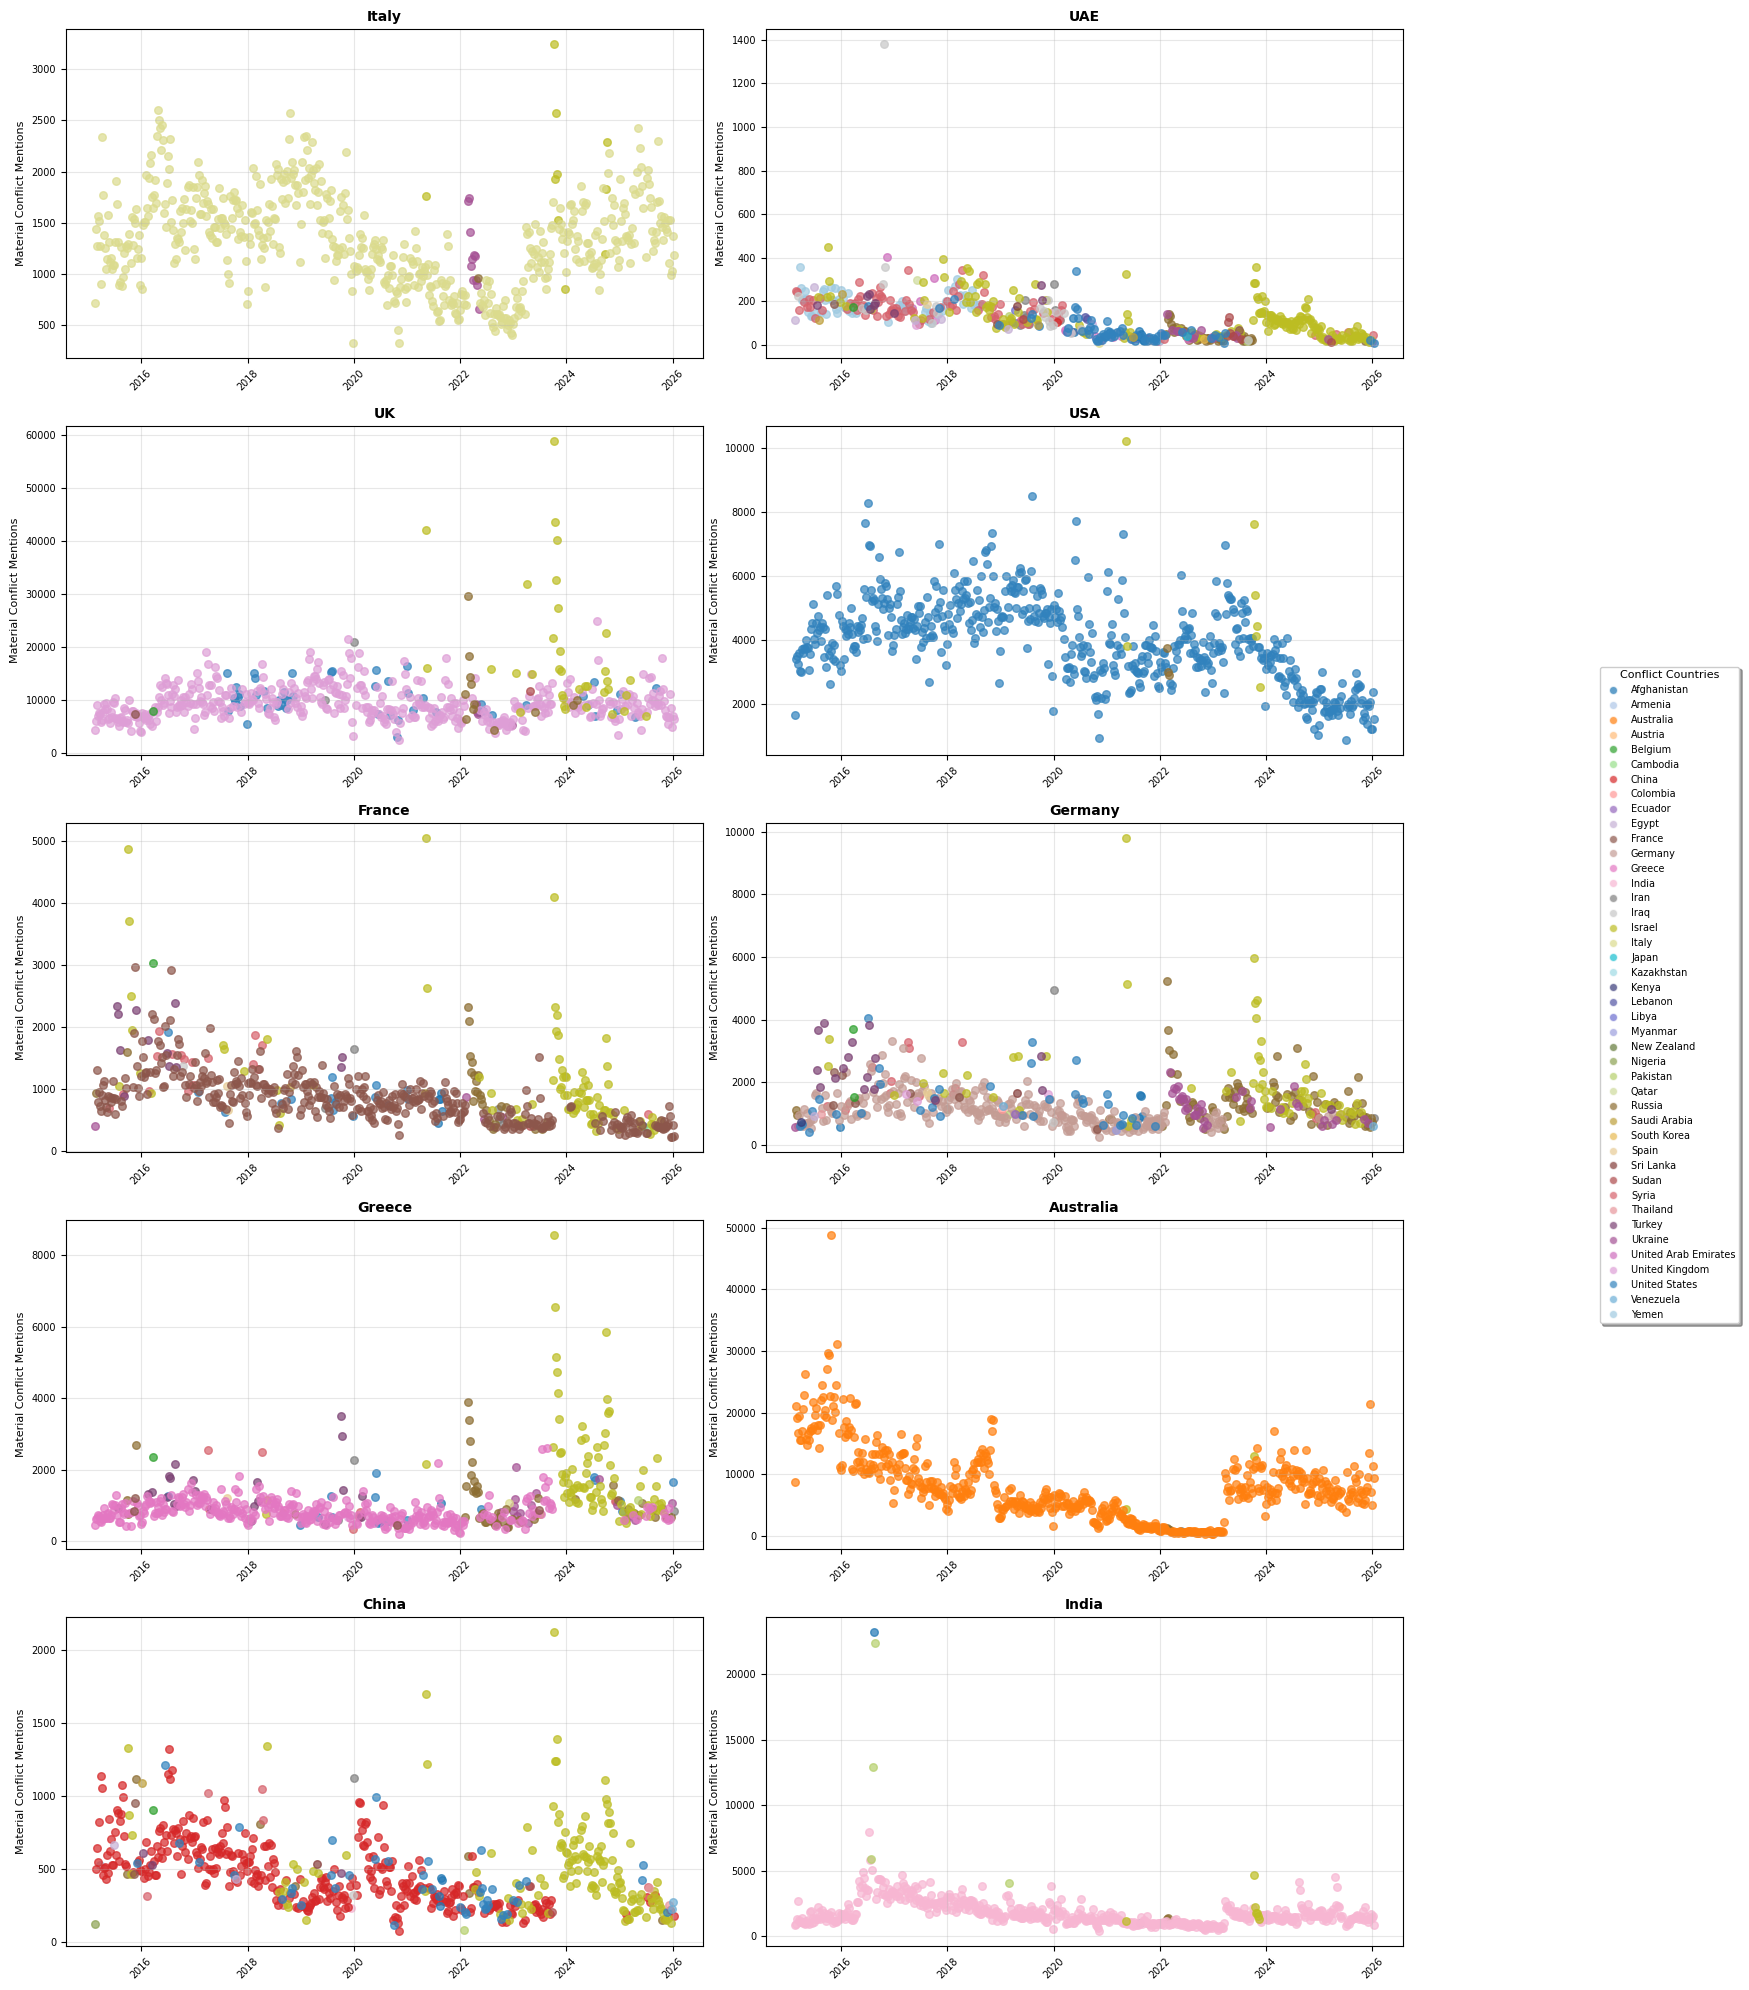

In [22]:
# Count actual countries to plot (excluding the 3 skipped ones)
countries_to_plot = [mc for mc in media_countries_filtered 
                     if mc not in ['LatAm (Left-Wing Block)', 'Other', 'Pan-Africa']]

# First pass: check which countries actually have data
countries_with_data = []
all_countries = set()

for media_country in countries_to_plot:
    country_key = media_country
    
    has_data = False
    for week, data in media_coverage_total[country_key].items():
        if data != {}:
            has_data = True
            all_countries.add(data['country_name'])
    
    #if has_data:
    countries_with_data.append(media_country)

n_countries = len(countries_with_data)

# Calculate grid size needed
n_cols = 2
n_rows = (n_countries + n_cols - 1) // n_cols  # Ceiling division

# Create the grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
if n_rows == 1:
    axes = [axes] if n_cols == 1 else axes
else:
    axes = axes.flatten()

# Create diverse color map with enough colors
all_countries = sorted(list(all_countries))
n_colors = len(all_countries)

# Use multiple color maps to get distinct colors
if n_colors <= 20:
    colors = plt.cm.tab20(range(n_colors))
else:
    # Combine multiple colormaps for more distinct colors
    colors1 = plt.cm.tab20(range(20))
    colors2 = plt.cm.tab20b(range(min(20, n_colors - 20)))
    colors3 = plt.cm.tab20c(range(max(0, n_colors - 40)))
    colors = list(colors1) + list(colors2) + list(colors3)
    colors = colors[:n_colors]

color_map = {country: colors[i] for i, country in enumerate(all_countries)}

# Plot each media country that has data
idx = 0
for media_country in countries_with_data:
    country_key = media_country
    
    weeks = []
    mentions = []
    country_names = []
    for week, data in media_coverage_total[country_key].items():
        if data != {}:
            weeks.append(week)
            mentions.append(data['mentions'])
            country_names.append(data['country_name'])
    
    weeks_dt = pd.to_datetime(weeks)
    ax = axes[idx]
    
    unique_countries = list(set(country_names))
    
    for country in unique_countries:
        indices = [i for i, c in enumerate(country_names) if c == country]
        ax.scatter([weeks_dt[i] for i in indices], [mentions[i] for i in indices], 
                   s=30, alpha=0.7, color=color_map[country])
    
    ax.set_title(f'{country_key}', fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)
    ax.set_ylabel('Material Conflict Mentions', fontsize=8)
    ax.grid(True, alpha=0.3)
    
    idx += 1

# Hide unused subplots (if any)
for i in range(idx, len(axes)):
    axes[i].set_visible(False)

# Create shared legend with smaller font if many countries
legend_fontsize = 7 if n_colors > 30 else 8
handles = [plt.Line2D([0], [0], marker='o', color='w', 
                      markerfacecolor=color_map[country], 
                      markersize=6, alpha=0.7, label=country) 
           for country in all_countries]

fig.legend(handles=handles, loc='center left', bbox_to_anchor=(1.0, 0.5), 
           fontsize=legend_fontsize, title='Conflict Countries', 
           title_fontsize=legend_fontsize+1, frameon=True, 
           fancybox=True, shadow=True)

plt.tight_layout()
plt.subplots_adjust(right=0.88)  # Make space for legend
plt.show()

In [23]:
# Load the json file for the map: ../src/json/world.json
geo_path = "../src/json/world.json"
with open(geo_path, 'r') as f:
    world_json = json.load(f)

geo_countries = set([feature['properties']['name'] for feature in world_json['features']])
# Countries in df_top_mentions_material not in geo_countries
missing_countries_material = set(df_top_mentions_material['media_country'].unique()) - geo_countries
print("Countries in df_top_mentions_material not in geo_countries:", missing_countries_material)

Countries in df_top_mentions_material not in geo_countries: {'UAE', 'Bahrain', 'Other', 'UK', 'Singapore', 'LatAm (Left-Wing Block)', 'USA', 'Pan-Africa'}


In [24]:
print('United Kingdom' in geo_countries)
print('United Arab Emirates' in geo_countries)
print('United States' in geo_countries)

True
True
True


### Datasets Creation

We will focus only on material conflict events from now on.

We are finally ready to create the datasets for the choropleth map and chord chart.

For the choropleth map we need the top 1 mention for each country and week and also some metadata like a label.

For the chord chart we need the top 5 mentions for each country and week and the same metadata.

First we finish cleaning the dataframe a bit more by dropping some unneeded columns and rows.

In [26]:
df_mentions_filtered_material['media_country'] = df_mentions_filtered_material['media_country'].replace({
    'UK': 'United Kingdom', 'UAE': 'United Arab Emirates', 'USA': 'United States'
})

C:\Users\HEW14SDQ1006NL\AppData\Local\Temp\ipykernel_12244\351907207.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mentions_filtered_material['media_country'] = df_mentions_filtered_material['media_country'].replace({


In [27]:
df_mentions_filtered_material = df_mentions_filtered_material[~df_mentions_filtered_material['media_country'].isin(['LatAm (Left-Wing Block)', 'Other', 'Pan-Africa'])]

In [29]:
df_mentions_filtered_material['media_country'].unique()

array(['Qatar', 'Lebanon', 'United States', 'South Africa', 'Australia',
       'Germany', 'Russia', 'France', 'China', 'Serbia', 'Belgium',
       'Romania', 'United Kingdom', 'United Arab Emirates', 'Croatia',
       'Greece', 'India', 'Bulgaria', 'Uganda', 'Spain', 'Colombia',
       'Switzerland', 'Sweden', 'Portugal', 'Mexico', 'Tunisia',
       'Slovakia', 'Ireland', 'Cuba', 'Afghanistan', 'Singapore',
       'Nigeria', 'Turkey', 'Ukraine', 'South Korea', 'Italy', 'Denmark',
       'Canada', 'Paraguay', 'Finland', 'Argentina', 'New Zealand',
       'Jordan', 'Poland', 'Austria', 'Pakistan', 'Malaysia',
       'Netherlands', 'Egypt', 'Brazil', 'Ghana', 'Japan', 'Kenya',
       'Israel', 'Uruguay', 'Zimbabwe', 'Iceland', 'Jamaica', 'Algeria',
       'Bangladesh', 'Costa Rica', 'Trinidad and Tobago', 'Hungary',
       'Senegal', 'Libya', 'Vietnam', 'Peru', 'Norway', 'Panama',
       'Saudi Arabia', 'Chile', 'Iran', 'Venezuela', 'Oman',
       'Philippines', 'Czech Republic', 'Nepal'

In [30]:
df_mentions_filtered_material['conflict_country_name'].unique()

array(['Somalia', 'Syria', 'South Africa', 'France', 'Colombia',
       'Romania', 'Indonesia', 'South Korea', 'Germany', 'Ukraine',
       'Russia', 'Australia', 'Japan', 'United Kingdom', 'United States',
       'Venezuela', 'Sri Lanka', 'Israel', 'Serbia', 'Italy', 'Turkey',
       'Pakistan', 'Uganda', 'Cuba', 'Guadeloupe', 'Iran', 'Honduras',
       'China', 'Switzerland', 'Mauritius', 'Norway', 'Greece',
       'Afghanistan', 'New Zealand', 'Bangladesh', 'Greenland', 'Niger',
       'Spain', 'Croatia', 'Latvia', 'Sudan', 'Denmark', 'Mexico', 'Iraq',
       'India', 'Solomon Islands', 'Netherlands', 'Cyprus', 'Hungary',
       'Lebanon', 'Saudi Arabia', 'Philippines', 'Jordan', 'Belgium',
       'Palestine', 'Thailand', 'Portugal', 'Yemen', 'Canada', 'Gambia',
       'Libya', 'Poland', 'Slovakia', 'Brazil', 'Tanzania', 'Hong Kong',
       'Egypt', 'Estonia', 'Costa Rica', 'Paraguay', 'Austria',
       'Bulgaria', 'Jamaica', 'Algeria', 'North Korea', 'Ireland',
       'Sweden', 'Cz

In [31]:
# Set difference between media_country and conflict_country_name
set(df_mentions_filtered_material['media_country'].unique()) - set(df_mentions_filtered_material['conflict_country_name'].unique())

set()

In [41]:
label_mapping = {
    'Africa': [
        'Somalia', 'South Africa', 'Uganda', 'Mauritius', 'Niger', 'Sudan', 'Gambia', 'Libya', 
        'Tanzania', 'Egypt', 'Algeria', 'Senegal', 'Liberia', 'Eritrea', 'Ethiopia', 'Ghana', 
        'Morocco', 'Cameroon', 'Nigeria', 'Kenya', 'Lesotho', 'Zimbabwe', 'Tunisia', 'Rwanda', 
        'Mozambique', 'Reunion', 'Mali', 'Democratic Republic of Congo', 'Benin', 'Guinea', 
        'Republic of Congo', 'Ivory Coast', 'Burkina Faso', 'Djibouti', 'Burundi', 'eSwatini', 
        'Chad', 'Angola', 'Central African Republic', 'Namibia', 'Sierra Leone', 'Equatorial Guinea', 
        'Togo', 'Cape Verde', 'Guinea-Bissau', 'Zambia', 'Mauritania', 'Madagascar', 'South Sudan', 
        'Mayotte', 'Botswana', 'Malawi', 'Sao Tome and Principe', 'Western Sahara', 
        'Saint Helena, Ascension and Tristan da Cunha', 'Seychelles', 'Comoros', 'Gabon'
    ],
    'Asia': [
        'Syria', 'Indonesia', 'South Korea', 'Japan', 'Sri Lanka', 'Israel', 'Turkey', 'Pakistan', 
        'Iran', 'China', 'Afghanistan', 'Bangladesh', 'Iraq', 'India', 'Lebanon', 'Saudi Arabia', 
        'Philippines', 'Jordan', 'Palestine', 'Thailand', 'Yemen', 'Hong Kong', 'Taiwan', 
        'Kazakhstan', 'United Arab Emirates', 'Malaysia', 'Kuwait', 'Brunei', 'Qatar', 'Vietnam', 
        'Myanmar', 'Cambodia', 'Oman', 'Singapore', 'Azerbaijan', 'Kyrgyzstan', 'Laos', 
        'Tajikistan', 'Nepal', 'Georgia', 'Uzbekistan', 'Maldives', 'Macau', 'Mongolia', 'Bahrain', 
        'Turkmenistan', 'East Timor', 'Bhutan', 'British Indian Ocean Territory', 'Spratly Islands', 
        'Paracel Islands', 'Armenia', 'North Korea'
    ],
    'Europe': [
        'France', 'Romania', 'Germany', 'Ukraine', 'Russia', 'United Kingdom', 'Serbia', 'Italy', 
        'Switzerland', 'Norway', 'Greece', 'Spain', 'Croatia', 'Latvia', 'Denmark', 'Netherlands', 
        'Cyprus', 'Hungary', 'Belgium', 'Portugal', 'Poland', 'Slovakia', 'Estonia', 'Austria', 
        'Bulgaria', 'Ireland', 'Sweden', 'Czech Republic', 'Lithuania', 'Iceland', 'Albania', 
        'Finland', 'Montenegro', 'Moldova', 'North Macedonia', 'Belarus', 'Kosovo', 'Vatican City', 
        'Svalbard', 'Malta', 'Slovenia', 'Bailiwick of Guernsey', 'Bosnia and Herzegovina', 
        'Bailiwick of Jersey', 'Gibraltar', 'Monaco', 'Liechtenstein', 'Luxembourg', 'Andorra', 
        'Faroe Islands', 'Isle of Man', 'San Marino'
    ],
    'North America': [
        'United States', 'Cuba', 'Guadeloupe', 'Honduras', 'Mexico', 'Costa Rica', 'Jamaica', 
        'Trinidad and Tobago', 'Panama', 'El Salvador', 'Guatemala', 'Belize', 'Bahamas', 
        'Saint-Martin', 'Haiti', 'Antigua and Barbuda', 'Dominican Republic', 'Aruba', 'Puerto Rico', 
        'Canada', 'Bermuda', 'Grenada', 'Saint Vincent and the Grenadines', 'Turks and Caicos Islands', 
        'Cayman Islands', 'British Virgin Islands', 'Martinique', 'Montserrat', 'Dominica', 
        'Saint Lucia', 'Anguilla', 'Caribbean Netherlands', 'Saint Pierre and Miquelon', 
        'Saint Kitts and Nevis', 'Greenland', 'Barbados', 'Virgin Islands, U.S.', 'Nicaragua'
    ],
    'South America': [
        'Colombia', 'Venezuela', 'Brazil', 'Paraguay', 'Peru', 'Ecuador', 'Argentina', 'Bolivia', 
        'Chile', 'Guyana', 'Uruguay', 'Suriname', 'French Guiana', 'Falkland Islands'
    ],
    'Oceania': [
        'Australia', 'New Zealand', 'Solomon Islands', 'Samoa', 'Fiji', 'Papua New Guinea', 
        'Palau', 'Kiribati', 'New Caledonia', 'Tonga', 'Vanuatu', 'American Samoa', 
        'Marshall Islands', 'Cook Islands', 'Nauru', 'Micronesia', 'Guam', 'Howland Island', 
        'Christmas Island', 'Tuvalu', 'Pitcairn', 'Norfolk Island', 'French Polynesia', 'Tokelau', 
        'Niue', 'Northern Mariana Islands', 'Wake Island', 'Oceans', 'Oceania'
    ],
    'Antarctica': [
        'Antarctica'
    ],
}

In [42]:
df_mentions_filtered_material.head()

,mention_week,conflict_country_name,media_country,material_conflict_mentions,material_conflict_unique_events,conflict_continent,media_continent
0,2026-01-12,Somalia,Qatar,10,10,Africa,Asia
1,2026-01-12,Syria,Lebanon,59,33,Asia,Asia
2,2026-01-12,South Africa,United States,6,6,Africa,North America
3,2026-01-12,France,South Africa,3,3,Europe,Africa
4,2026-01-12,Colombia,Australia,0,0,South America,Oceania


In [43]:
# Adding two new columns: 'conflict_continent' and 'media_continent' based on the label_mapping
def country_to_continent(country):
    for continent, countries in label_mapping.items():
        if country in countries:
            return continent
    return 'Other'  # For countries not found in the mapping

df_mentions_filtered_material['conflict_continent'] = df_mentions_filtered_material['conflict_country_name'].apply(country_to_continent)
df_mentions_filtered_material['media_continent'] = df_mentions_filtered_material['media_country'].apply(country_to_continent)
df_mentions_filtered_material.head()

,mention_week,conflict_country_name,media_country,material_conflict_mentions,material_conflict_unique_events,conflict_continent,media_continent
0,2026-01-12,Somalia,Qatar,10,10,Africa,Asia
1,2026-01-12,Syria,Lebanon,59,33,Asia,Asia
2,2026-01-12,South Africa,United States,6,6,Africa,North America
3,2026-01-12,France,South Africa,3,3,Europe,Africa
4,2026-01-12,Colombia,Australia,0,0,South America,Oceania


In [46]:
# Choropleth map dataset:
df_top_1_mentions_material = df_mentions_filtered_material.sort_values('material_conflict_mentions', ascending=False).groupby(['media_country', 'mention_week']).head(1)
df_top_1_mentions_material = df_top_1_mentions_material.sort_values(by=['mention_week', 'media_country'])
df_top_1_mentions_material.head()

,mention_week,conflict_country_name,media_country,material_conflict_mentions,material_conflict_unique_events,conflict_continent,media_continent
1897037,2015-02-16,Afghanistan,Afghanistan,66,58,Asia,Asia
1894183,2015-02-16,Libya,Algeria,6,6,Africa,Africa
1896566,2015-02-16,Argentina,Argentina,610,186,South America,South America
1894901,2015-02-16,Australia,Australia,8753,1306,Oceania,Oceania
1894357,2015-02-16,Ukraine,Austria,143,49,Europe,Europe


In [47]:
# Save as csv df_top_mentions_material 
output_path = "../data/processed/choropleth_top_1_material_conflict.csv"
df_top_1_mentions_material.to_csv(output_path, index=False)

In [48]:
# Chord diagram dataset:
n = 5
df_top_n_mentions_material = df_mentions_filtered_material.sort_values('material_conflict_mentions', ascending=False).groupby(['media_country', 'mention_week']).head(n)
df_top_n_mentions_material = df_top_n_mentions_material.sort_values(by=['mention_week', 'media_country'])
df_top_n_mentions_material.head()

,mention_week,conflict_country_name,media_country,material_conflict_mentions,material_conflict_unique_events,conflict_continent,media_continent
1897037,2015-02-16,Afghanistan,Afghanistan,66,58,Asia,Asia
1896630,2015-02-16,Pakistan,Afghanistan,24,17,Asia,Asia
1896860,2015-02-16,United States,Afghanistan,5,5,North America,Asia
1895645,2015-02-16,Turkey,Afghanistan,0,0,Asia,Asia
1894183,2015-02-16,Libya,Algeria,6,6,Africa,Africa


In [49]:
# Save as csv df_top_n_mentions_material 
output_path = "../data/processed/chord_top_5_material_conflict.csv"
df_top_n_mentions_material.to_csv(output_path, index=False)

Now for a line chart I need to save as csv df_mentions_filtered_material

In [51]:
# Save as csv df_mentions_filtered_material
output_path = "../data/processed/line_chart_material_conflict_with_unique_events.csv"
df_mentions_filtered_material.to_csv(output_path, index=False)

In [52]:
# Dropping the 'material_conflict_unique_events' and 'media_continent', 'media_country' columns
df_mentions_filtered_material = df_mentions_filtered_material.drop(columns=['material_conflict_unique_events', 'media_continent', 'media_country'])
df_mentions_filtered_material.head()

,mention_week,conflict_country_name,material_conflict_mentions,conflict_continent
0,2026-01-12,Somalia,10,Africa
1,2026-01-12,Syria,59,Asia
2,2026-01-12,South Africa,6,Africa
3,2026-01-12,France,3,Europe
4,2026-01-12,Colombia,0,South America


In [53]:
# Save as csv df_mentions_filtered_material
output_path = "../data/processed/line_chart_material_conflict.csv"
df_mentions_filtered_material.to_csv(output_path, index=False)

In [62]:
# Grouping by 'mention_week', 'conflict_country_name' and 'conflict_continent' to sum 'material_conflict_mentions' and
# to find the 3 conflict countries per week with highest cumulative 'material_conflict_mentions' and to save them to a new dataframe
df_grouped_top_3 = df_mentions_filtered_material.groupby(
    ['mention_week', 'conflict_country_name', 'conflict_continent']
)['material_conflict_mentions'].sum().reset_index()

df_grouped_top_3 = df_grouped_top_3.sort_values(
    'material_conflict_mentions', ascending=False
).groupby('mention_week').head(3)

df_grouped_top_3 = df_grouped_top_3.sort_values(
    by=['mention_week', 'material_conflict_mentions'], 
    ascending=[True, False]
)


In [67]:
df_grouped_top_3.tail(24)

,mention_week,conflict_country_name,conflict_continent,material_conflict_mentions
103007,2025-11-24,United States,North America,20042
102976,2025-11-24,Russia,Europe,12099
102916,2025-11-24,Israel,Asia,11922
103178,2025-12-01,United States,North America,27214
103146,2025-12-01,Russia,Europe,12448
103024,2025-12-01,Australia,Oceania,10236
103194,2025-12-08,Australia,Oceania,23795
103355,2025-12-08,United States,North America,17341
103320,2025-12-08,Russia,Europe,12418
103370,2025-12-15,Australia,Oceania,38515


In [68]:
# Save as csv df_grouped_top_3
output_path = "../data/processed/weekly_top_3_material_conflict.csv"
df_grouped_top_3.to_csv(output_path, index=False)